You can find the lecture [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/lectures/L04_probability.ipynb)

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
z= np.loadtxt('dr7qso.dat',skiprows=80, usecols=3)
hist, bin_edges = np.histogram(z,density=True)

## Upsample with rejection

- pick a uniform distribution $q(z)$ over `np.min(z)` and `np.max(z)`
- draw a random $z_i$ in the region 
- draw a random number $u$ from the uniform distribution over $[0,\max(h(x)]$
- if $u<h(z_i)$, accept the point or else reject.

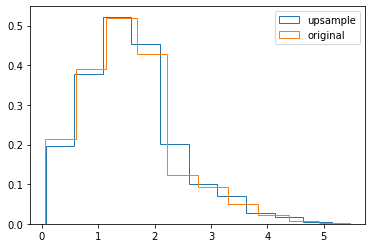

In [10]:
N=10**4 #overall draws
zi=np.random.uniform(np.min(z),np.max(z),N)
#------------------------
ui=np.random.uniform(0,max(hist),N)
#------------------------
# assign zi to one bin i, then hi=hist[i]
bin_i=np.searchsorted(bin_edges,zi,side='right')-1
hi=hist[bin_i]
#------------------------
accepted_zi=zi[ui<hi]
#------------------------
plt.hist(accepted_zi,histtype='step',density=True,label='upsample');
plt.hist(z,histtype='step',density=True,label='original');
plt.legend()
plt.show()